In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as pty


weather_forecast_data = pd.read_csv('dataset/weather_forecast_data.csv')

# EDA

In [3]:
weather_forecast_data.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [4]:
weather_forecast_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   str    
dtypes: float64(5), str(1)
memory usage: 117.3 KB


In [5]:
weather_forecast_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,2500.0,22.581725,7.326996,10.001842,16.359398,22.536448,28.976476,34.995214
Humidity,2500.0,64.347094,19.954739,30.005071,47.339815,63.920797,81.561021,99.997481
Wind_Speed,2500.0,9.906255,5.780316,0.009819,4.761909,9.908572,14.948408,19.999132
Cloud_Cover,2500.0,49.658104,29.123104,0.015038,23.900016,49.488284,75.324140,99.997795
Pressure,2500.0,1014.312336,20.196433,980.014486,996.938630,1013.433035,1031.735067,1049.985593


In [6]:
weather_forecast_data['Rain'].value_counts()

Rain
no rain    2186
rain        314
Name: count, dtype: int64

In [7]:
weather_forecast_data['Rain'].value_counts(normalize=True)

Rain
no rain    0.8744
rain       0.1256
Name: proportion, dtype: float64

In [22]:
weather_forecast_data.columns

Index(['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure',
       'Rain'],
      dtype='str')

Change rain to a binary number instead of a string

In [24]:
weather_forecast_data['Rain'] = weather_forecast_data['Rain'].map({'rain': 1, 'no rain': 0})
weather_forecast_data.head(1)

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,1


##### Check correlation between data against the Rain column using a heatmap (seaborn)

<Axes: >

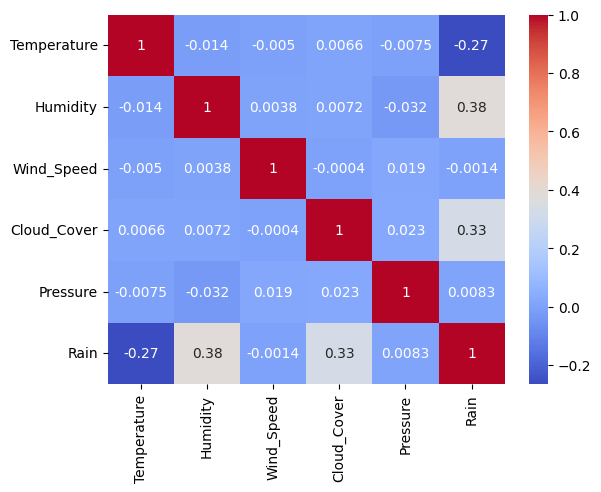

In [27]:
sns.heatmap(weather_forecast_data.corr(), annot=True, cmap='coolwarm')

# Decision Tree Model

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree # Decision Tree visualizations

##### Split Data

In [28]:
X = weather_forecast_data.iloc[:, 0:5]
y = weather_forecast_data.iloc[:, 5]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.60) # Keeps the same random state and makes the train test split 80/20

##### Run Grid Search algo (hyperparameter tuning) to find the best hyperparameters

In [29]:
params = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 10, 15, 20, 30],
    'min_samples_leaf': [1, 2, 5, 10, 15, 20]
}

grid_search = GridSearchCV(DecisionTreeClassifier(), params, cv=5, scoring='accuracy')
# Uses Decision Tree as the model to determine best parameters
# Uses the combination of parameters we defined above
# Uses 5 folds as the splitting
# Uses accuracy as the scoring metric to find the best parameters

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

{'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}


##### Create Decision Tree using the best parameters found in Grid Search above and train/fit the model

In [30]:
dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, min_samples_split=2)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

##### Test the model and analyze performance

In [31]:
y_pred = dt.predict(X_test)

In [32]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1325    0]
 [  16  159]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1325
           1       1.00      0.91      0.95       175

    accuracy                           0.99      1500
   macro avg       0.99      0.95      0.97      1500
weighted avg       0.99      0.99      0.99      1500



##### Visualize the tree

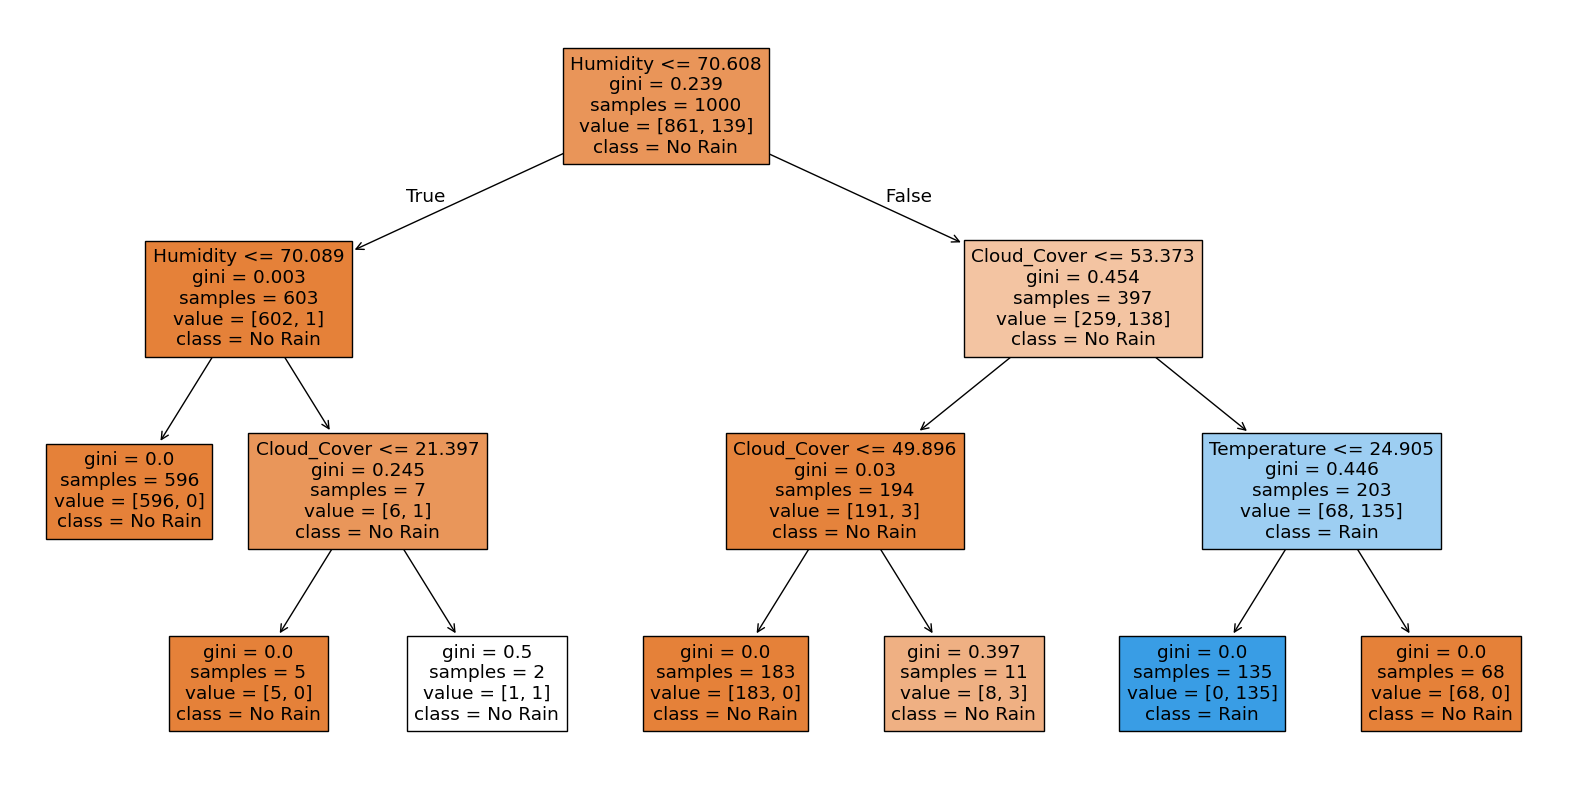

In [34]:
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=['No Rain', 'Rain'], filled=True)
plt.show()

Due to the dataset being small and self generated from Kaggle, the model is overfitting even even when using the best parameters.

I increased the test size to 0.50 from 0.20 and that seemed to help with the model training, but even then iit is overfitting.